In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_measurements = pd.read_csv('hwg_measurements.csv')
df_subjects = pd.read_csv('hwg_metadata.csv', skiprows=4)

# Join the two tables together on subject_id, keeping only rows that exist in both tables
df_raw = pd.merge(df_subjects, df_measurements, on='subject_id', how='inner')

# Create a bmi field
df_raw['bmi'] = df_raw['weight_kg'] / (df_raw['height_cm'] / 100) ** 2

# Convert gender to an is_male column (1 = male, 0 = female)
df_raw['is_male'] = df_raw['gender'].apply(lambda x: 1 if x == 'male' else 0)

# Keep only a few columns for easier analysis
# is_male, height_cm, weight_kg, bmi, arm-length
df = df_raw[['height_cm', 'is_male', 'weight_kg', 'bmi', 'arm-length']].copy()

df.head()

,height_cm,is_male,weight_kg,bmi,arm-length
0,160.00,0,92.4,36.093750,46.422310
1,175.75,0,102.8,33.281466,53.050766
2,174.80,1,106.9,34.986045,52.061996
3,181.50,1,111.8,33.938180,52.575706
4,161.60,0,93.0,35.612317,46.116558


In [11]:
# calculate correlation and p value between bmi and weight_kg
from scipy import stats
corr, p_value = stats.pearsonr(df['bmi'], df['weight_kg'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.3e}")


Correlation: 0.858, p-value: 0.000e+00


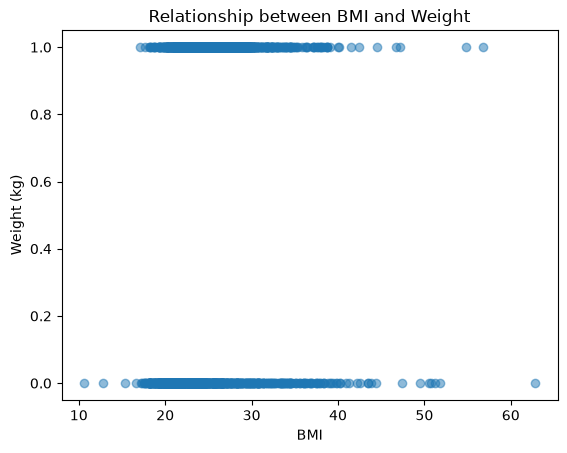

In [13]:
# plot bmi and weight_kg in a scatterplot
import matplotlib.pyplot as plt

plt.scatter(df['bmi'], df['is_male'], alpha=0.5)
plt.xlabel('BMI')
plt.ylabel('Weight (kg)')
plt.title('Relationship between BMI and Weight')
plt.show()

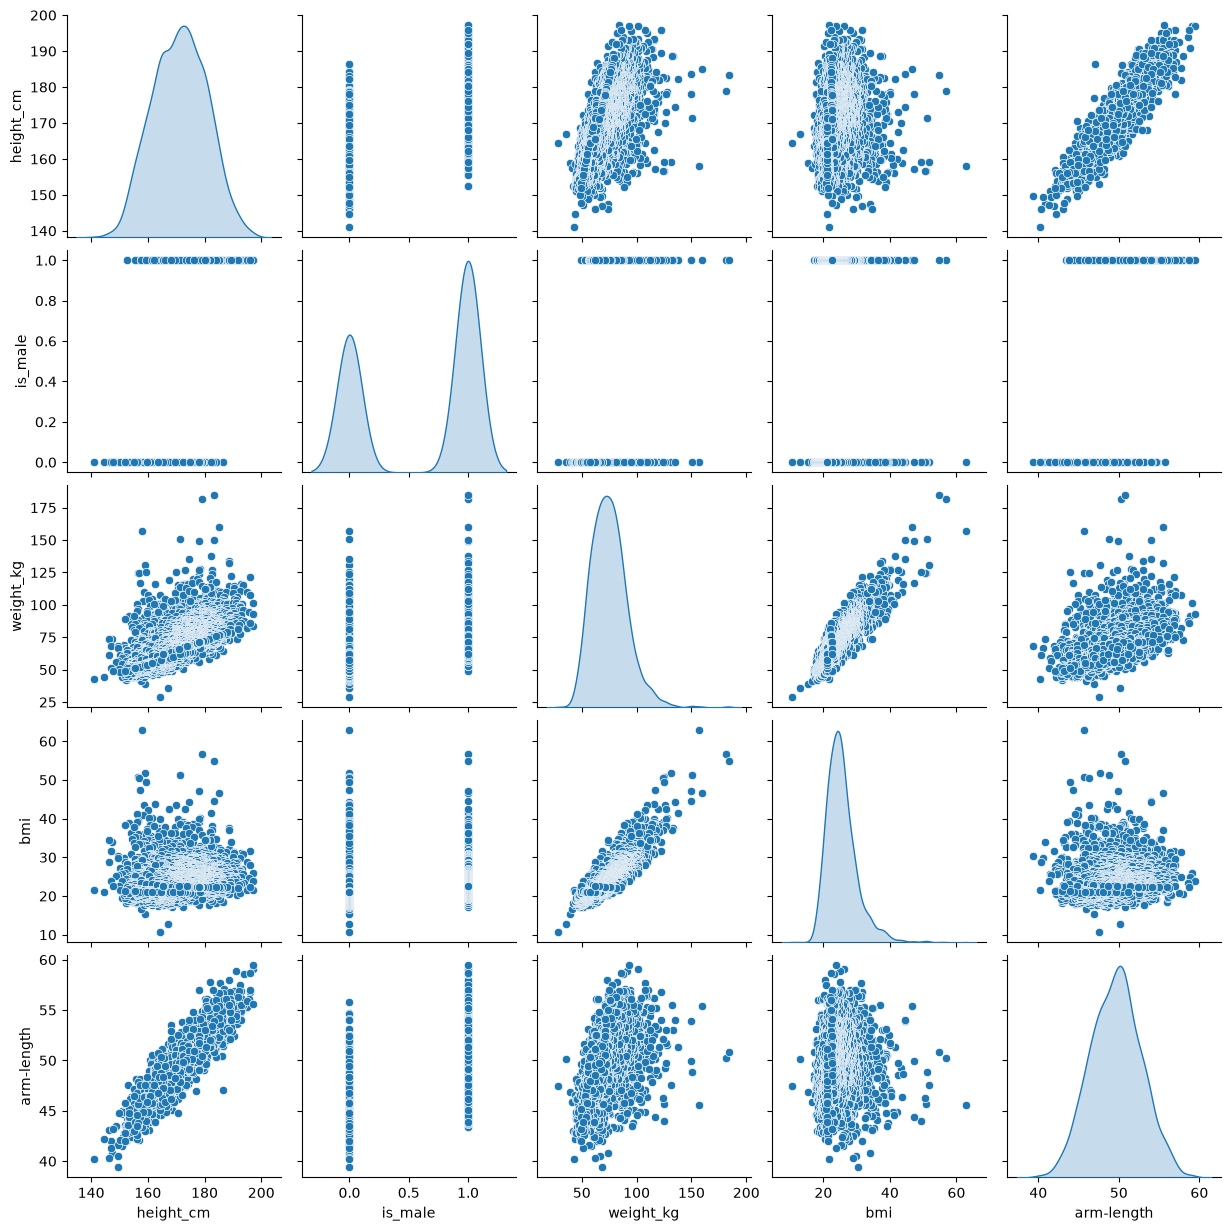

In [14]:
# create a pairplot of the data
sns.pairplot(df,  diag_kind='kde')


In [16]:
# Calcuate the correlation matrix and p-values for all pairs of columns
p_values = pd.DataFrame(np.ones((df.shape[1], df.shape[1])),
                        columns=df.columns,
                        index=df.columns)
for a in df.columns:
    for b in df.columns:
        if a != b:
            p_values.loc[a, b] = stats.pearsonr(df[a], df[b])[1]

# print the correlation matrix
corr_matrix = df.corr()
print("Correlation Matrix:")
print(corr_matrix)

# print the p-values
print("P-Values:")
# round values to 3 decimal places for easier reading
p_values = p_values.round(3)
print(p_values)

Correlation Matrix:
            height_cm   is_male  weight_kg       bmi  arm-length
height_cm    1.000000  0.672827   0.550857  0.054896    0.906015
is_male      0.672827  1.000000   0.413662  0.092072    0.617156
weight_kg    0.550857  0.413662   1.000000  0.857944    0.468253
bmi          0.054896  0.092072   0.857944  1.000000    0.015208
arm-length   0.906015  0.617156   0.468253  0.015208    1.000000
P-Values:
            height_cm  is_male  weight_kg    bmi  arm-length
height_cm       1.000      0.0        0.0  0.014       0.000
is_male         0.000      1.0        0.0  0.000       0.000
weight_kg       0.000      0.0        1.0  0.000       0.000
bmi             0.014      0.0        0.0  1.000       0.497
arm-length      0.000      0.0        0.0  0.497       1.000
